In [1]:
# Import the modules of interest
import ee
import matplotlib.pyplot as plt

# import branca.colormap as cm
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from mpl_toolkits.axes_grid1 import make_axes_locatable

import sys

sys.path.append("..")

from utils.plotting_utils import (
    get_geometries,
    get_color_palettes,
    get_global_img_mosaic,
    url_to_image,
    get_dimensions_bbox,
)

ee.Initialize(project="ee-speckerfelix")

In [2]:
colors = get_color_palettes()

In [3]:
# -------------------------
# 3) Vis params per row (shared across columns)
# -------------------------
# Reuse your palettes/norms; placeholders below assume you already have norms/cmaps.
# Recommended: same cmap for all std rows (e.g. std_cmap), different norm per component if needed.
def get_vis(trait):
    return {
        "mean": {
            **colors[f"{trait}_visparams"],  # min/max/palette if you store them there
            "cmap": colors[f"{trait}_cmap"],
            "norm": colors[f"{trait}_norm"],
        },
        "count": {
            **colors["count_visparams"],
            "cmap": colors["count_cmap"],
            "norm": colors["count_norm"],
        },
        "stdDev": {
            **colors[f"{trait}_std_visparams"],
            "cmap": colors["std_cmap"],
            "norm": colors[f"std_{trait}_norm"],
        },
        "stdDev_within": {
            # you may want separate norms for within/across to avoid saturating
            **colors.get(
                f"{trait}_std_within_visparams", colors[f"{trait}_std_visparams"]
            ),
            "cmap": colors["std_cmap"],
            "norm": colors.get(f"std_within_{trait}_norm", colors[f"std_{trait}_norm"]),
        },
        "stdDev_across": {
            **colors.get(
                f"{trait}_std_across_visparams", colors[f"{trait}_std_visparams"]
            ),
            "cmap": colors["std_cmap"],
            "norm": colors.get(f"std_across_{trait}_norm", colors[f"std_{trait}_norm"]),
        },
    }


vis_laie = get_vis("laie")
vis_fcover = get_vis("fcover")
vis_fapar = get_vis("fapar")

vis = {"laie": vis_laie, "fcover": vis_fcover, "fapar": vis_fapar}

In [4]:
geometries = get_geometries()["point_geoms_figs4"]

buffer_size = 50000
buffered_geoms = {k: v.buffer(buffer_size).bounds() for k, v in geometries.items()}


In [5]:
laie = get_global_img_mosaic("laie", resolution="100m", year=2020, version="v03")
fcover = get_global_img_mosaic("fcover", resolution="100m", year=2020, version="v03")
fapar = get_global_img_mosaic("fapar", resolution="100m", year=2020, version="v03")

laie_mean = laie.select("laie_mean")
laie_std = laie.select("laie_stdDev")
laie_count = laie.select("laie_count")
fcover_mean = fcover.select("fcover_mean")
fcover_std = fcover.select("fcover_stdDev")
fcover_count = fcover.select("fcover_count")
fapar_mean = fapar.select("fapar_mean")
fapar_std = fapar.select("fapar_stdDev")
fapar_count = fapar.select("fapar_count")

In [6]:
## image urls
laie_mean_url = laie_mean.getThumbURL(
    {
        "region": buffered_geoms["amazon"],
        "dimensions": 512,
        **vis_laie["mean"],
    }
)

laie_std_url = laie_std.getThumbURL(
    {
        "region": buffered_geoms["amazon"],
        "dimensions": 512,
        **vis_laie["stdDev"],
    }
)

laie_count_url = laie_count.getThumbURL(
    {
        "region": buffered_geoms["amazon"],
        "dimensions": 512,
        **vis_laie["count"],
    }
)

fcover_mean_url = fcover_mean.getThumbURL(
    {
        "region": buffered_geoms["india"],
        "dimensions": 512,
        **vis_fcover["mean"],
    }
)

fcover_std_url = fcover_std.getThumbURL(
    {
        "region": buffered_geoms["india"],
        "dimensions": 512,
        **vis_fcover["stdDev"],
    }
)

fcover_count_url = fcover_count.getThumbURL(
    {
        "region": buffered_geoms["india"],
        "dimensions": 512,
        **vis_fcover["count"],
    }
)

fapar_mean_url = fapar_mean.getThumbURL(
    {
        "region": buffered_geoms["borneo"],
        "dimensions": 512,
        **vis_fapar["mean"],
    }
)

fapar_std_url = fapar_std.getThumbURL(
    {
        "region": buffered_geoms["borneo"],
        "dimensions": 512,
        **vis_fapar["stdDev"],
    }
)

fapar_count_url = fapar_count.getThumbURL(
    {
        "region": buffered_geoms["borneo"],
        "dimensions": 512,
        **vis_fapar["count"],
    }
)

print(laie_mean_url)
print(laie_std_url)
print(laie_count_url)
print(fcover_mean_url)
print(fcover_std_url)
print(fcover_count_url)
print(fapar_mean_url)
print(fapar_std_url)
print(fapar_count_url)

urls = {
    "laie": {
        "mean": laie_mean_url,
        "stdDev": laie_std_url,
        "count": laie_count_url,
    },
    "fcover": {
        "mean": fcover_mean_url,
        "stdDev": fcover_std_url,
        "count": fcover_count_url,
    },
    "fapar": {
        "mean": fapar_mean_url,
        "stdDev": fapar_std_url,
        "count": fapar_count_url,
    },
}

https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/ca3ace6bcaa77f4b660e0927ae87c98a-cb739f2ea3fe18b211f25a589c2679ce:getPixels
https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/161806da5a331a0b9091455a64760afc-78e5f802393367c6fc8090eed12c3d9f:getPixels
https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/7eae40f02962564d478af4b0d03911b8-12ea33aea75d5c0daab541d83a6b4483:getPixels
https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/128c397247315ed25983fb324a22b4c7-2beaa0eb955ef9687ee805d2560659ae:getPixels
https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/c61e7f175ea0484d0bb83f445aee1dd1-5aea214767986bc7701828e9240ed364:getPixels
https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/a576c52bd0d5630e630343899b74e636-e3b951ecaa767ed6c4114464f658e436:getPixels
https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/36103d2b0e261c2521a146dd33

In [8]:
# print sizes of bounding boxes
print("Amazon", get_dimensions_bbox(buffered_geoms["amazon"]))
print("India", get_dimensions_bbox(buffered_geoms["india"]))
print("Borneo", get_dimensions_bbox(buffered_geoms["borneo"]))

Amazon (99496.92055731932, 99484.60410022103)
India (99935.99581633265, 99667.54220069536)
Borneo (99525.1213409315, 99484.28810566783)


/var/folders/83/2r2r5qp14398cnm45nnlt7080000gn/T/ipykernel_52809/1579349941.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


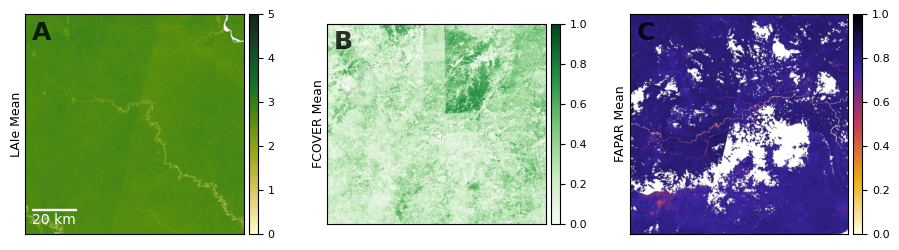

Saved: figure-s4_mean.png


/var/folders/83/2r2r5qp14398cnm45nnlt7080000gn/T/ipykernel_52809/1579349941.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


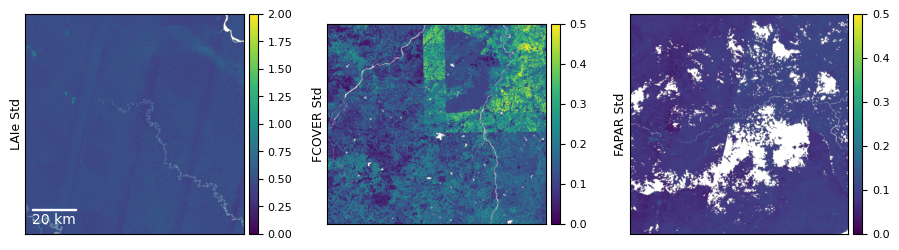

Saved: figure-s4_stdDev.png


/var/folders/83/2r2r5qp14398cnm45nnlt7080000gn/T/ipykernel_52809/1579349941.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


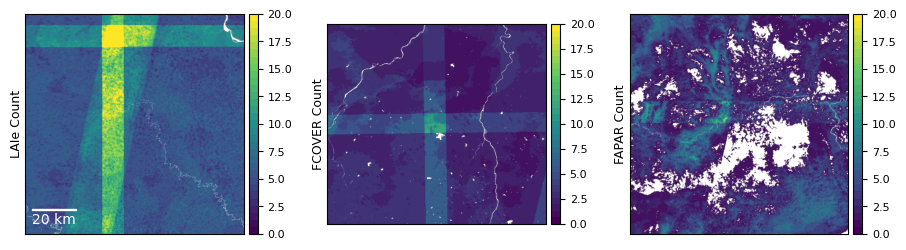

Saved: figure-s4_count.png


In [16]:
import matplotlib.font_manager as fm

trait_site_tuple = (("LAIe", "amazon"), ("FCOVER", "india"), ("FAPAR", "borneo"))

bands = ["mean", "stdDev", "count"]

buffer_m = 50000
scalebar_length_m = 20000
scalebar_label = "20 km"
thumb_px = 512

col_letters = ["A", "B", "C"]

band_label_dict = {
    "mean": "Mean",
    "stdDev": "Std",
    "count": "Count",
}

for band_key in bands:
    fig, axs = plt.subplots(
        1,
        3,
        figsize=(3.6 * 3, 3.4),
        gridspec_kw={"wspace": 0.30},  # more space for colorbars
    )

    for j, (trait, site_key) in enumerate(trait_site_tuple):
        ax = axs[j]
        img = url_to_image(urls[trait.lower()][band_key])
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])

        h, w = img.shape[0], img.shape[1]
        ax.set_xlim(0, w)
        ax.set_ylim(h, 0)

        # --------------------------------------------------
        # Column letters (only for MEAN figure)
        # --------------------------------------------------
        if band_key == "mean":
            ax.text(
                0.03,
                0.97,
                col_letters[j],
                transform=ax.transAxes,
                fontsize=18,
                fontweight="bold",
                color="black",
                alpha=0.8,
                ha="left",
                va="top",
            )

        # --------------------------------------------------
        # Individual colorbar for this subplot
        # --------------------------------------------------
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="4%", pad=0.05)

        sm = cm.ScalarMappable(
            norm=vis[trait.lower()][band_key]["norm"],
            cmap=vis[trait.lower()][band_key]["cmap"],
        )

        cb = fig.colorbar(sm, cax=cax)
        cb.ax.tick_params(labelsize=8)

        # title on the left side of the image
        ax.text(
            -0.01,
            0.5,
            f"{trait} {band_label_dict[band_key]}",
            transform=ax.transAxes,
            rotation=90,
            va="center",
            ha="right",
            fontsize=9,
        )

    # --------------------------------------------------
    # Scale bar only on first subplot
    # --------------------------------------------------
    ax0 = axs[0]

    total_image_size_meters = buffer_m * 2
    pixel_size = total_image_size_meters / thumb_px
    scalebar_len_px = scalebar_length_m / pixel_size

    scalebar = AnchoredSizeBar(
        ax0.transData,
        scalebar_len_px,
        scalebar_label,
        loc="lower left",
        pad=0.4,
        color="white",
        frameon=False,
        size_vertical=2,
        fontproperties=fm.FontProperties(size=10),
    )

    ax0.add_artist(scalebar)

    # --------------------------------------------------
    # Export
    # --------------------------------------------------
    fig.tight_layout()
    outname = f"figure-s4_{band_key}.png"
    fig.savefig(outname, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()

    # also save to pdf
    fig.savefig(f"figure-s4_{band_key}.pdf", bbox_inches="tight", pad_inches=0.02)

    print("Saved:", outname)
